In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("data/Telco_customer_churn.csv")

# Stage 2: Exploratory Data Analysis & Pre-Processing of Telco's Customer Churn

### This section explores the dataset, understanding and preparing the dataset before processing the model.

**Objective:** Explore the data, Check data quality, Visualise patterns, & prepare the data for modelling 

Group 11: Tai Jing, Kael Maliqc Chong, Ayan Ahmad, Muhammad Pratama

### Univariate Analysis : initial exploration of data.


**Customer Churn Distribution**

The bar chart below illustrates the distribution of customers who churned against those who remained with the telecom service. Out of a total of 7,043 customers, approximately 5,174 (73%) did not churn, while 1,869 customers (27%) discontinued the service. 

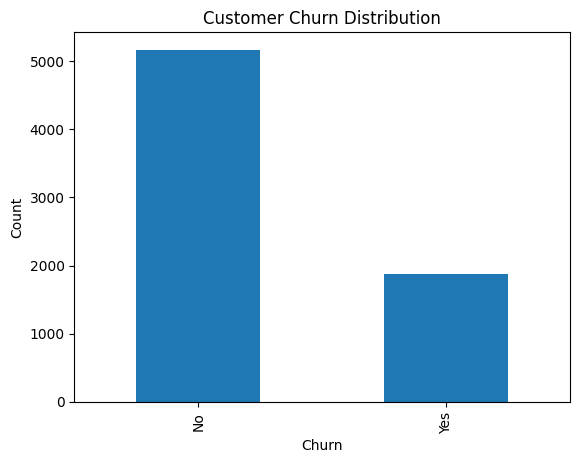

In [2]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

**Business Intelligence Implications**

The distribution indicates that while the majority of customers remain with the company, a significant amount of customers continue to leave the service. A churn rate of +-27% suggests customer attrition represents a meaningful business issue that requires further evaluation. From a business perspective, customer churn directly affects revenue and customer lifetime value. Losing over a quarter of the customer base leads to substantial revenue loss and increased customer acquisition costs. Therefore, understanding the factors that drive churn is essential for developing retention strategies.

To better understand potential factors influencing customer churn, it is necessary to explore key customer characteristics within Telco's dataset.  Variables such as customer tenure and monthly charges may provide insight into customer behaviour and service engagement. The following visualisations examine the distribution of these variables to identify patterns, anomalies, or trends that may associate with customer retention or churn.

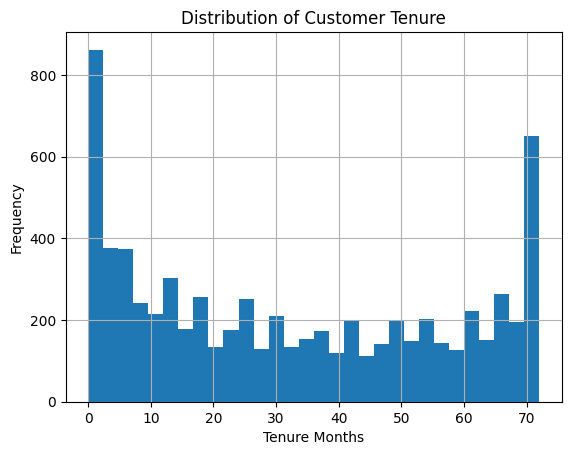

In [3]:
df["Tenure Months"].hist(bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Frequency")
plt.show()

The distribution of customer tenure shows the length of time customers have remained subscribed to the telecom service. The histogram indicates a higher concentration of customers with shorter tenure periods, suggesting that many customers are new to the service. In analysing churn, tenure is often an important indicator of customer loyalty as customers become more intimate and familiar with a brand over the relationship tenure. (Krautz and Hoffmann, 2017). This pattern will be explored further in later stages when examining the relationship between tenure and churn.

Furthermore, pricing is another factor that may influence customer churn. Customers facing higher monthly costs may be more likely to discontinue or change to another service if they perceive insufficient value.

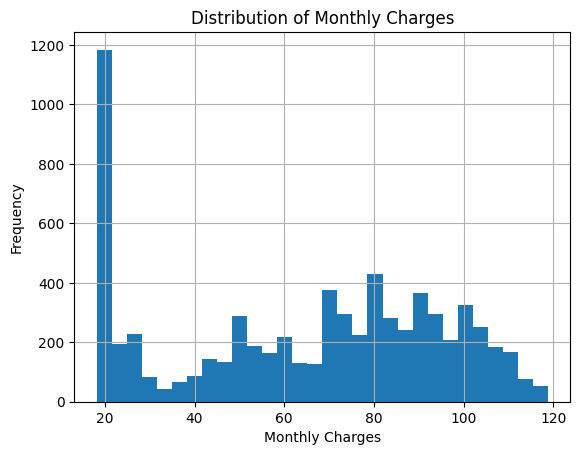

In [4]:
df["Monthly Charges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

The histogram of monthly charges illustrates the distribution of subscription costs across the customer base. The distribution reveals a wide range of monthly charges, reflecting the different services selected by customers. Several clusters can be observed across the pricing, suggesting the presence of multiple service tiers offered by the provider. 

From a BI perspective, pricing differences may influence customer satisfaction and perceived value, which could ultimately affect churn behaviour. Customers paying higher monthly charges may be more sensitive to price changes or competing offers in the market.

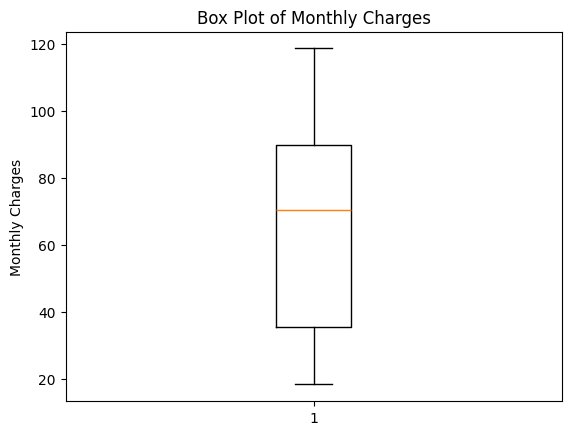

In [5]:
plt.boxplot(df["Monthly Charges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

The box plot of monthly charges provides a complementary view of the pricing distribution by highlighting the median, quartiles, and overall spread of values. The median monthly charge is approximately £70, indicating the typical price paid by customers. The interquartile range shows that the middle 50% of customers pay between £35 - £90 per month, suggesting considerable variation in service pricing across the customer base. From a business perspective, this variation in pricing may influence customer perceptions of value and affordability, which could potentially affect churn behaviour.

While monthly charges represent the recurring cost of telecom services, it is also important to examine the total amount customers have paid over their relationship with the company. Total charges provide insight into customer lifetime value and reflect both the duration of service usage and the level of monthly expenditure. 

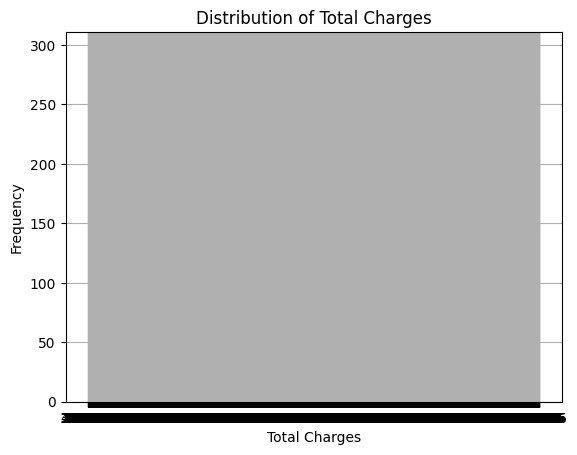

In [6]:
df["Total Charges"].dropna().hist(bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

This histogram illustrates the cumulative amount customers have paid for services over time. The graph is noticeably asymmetric with a right-skewed distribution, as a large amount of customers have relatively low total charges, while a small number of customers accumulate significantly higher values.

This pattern further proves that many customers are either relatively new to the service, or have discontinued their subscription before accumulating large total charges. Conversely, customers with high total charges are likely those who have maintained longer relationships with the telecom service or subscribed to higher value plans. From a BI perspective, total charges can act as an indicator of customer lifetime value, highlighting the importance of retaining customers.

## Bivariate / Multivariate Analysis

**Analysis on customer churn against a variety of factors.**

While the previous visualisations focused on understanding the distribution of individual variables, it is also important to look into how various customer characteristics relate directly to churn behaviour. The following section therefore explores relationships between key variables and churn outcomes using bivariate and multivariate analysis.

In [7]:
# Contract type against churn (shows strong churn pattern)
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [8]:
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**7. Churn by Contract Type.**

Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


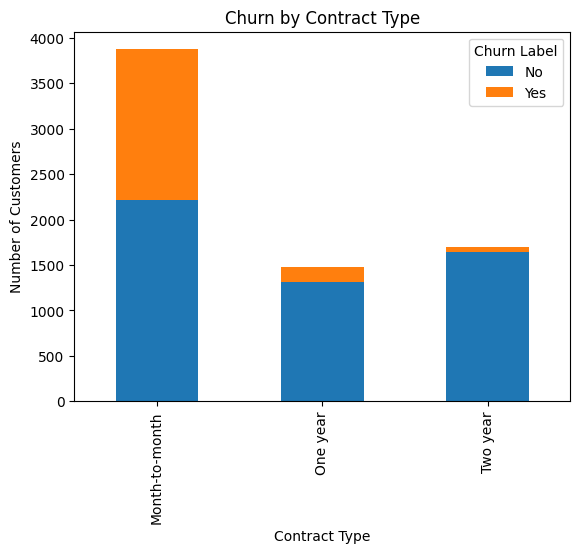

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# churn vs contract
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

print(contract_churn)

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

This analysis examines the relationship between contract type and customer churn. By comparing churn across different contract categories (month-to-month, one-year, and two-year), we can identify whether contract duration influences customer retention. Typically, customers on shorter contracts are more likely to churn due to lower commitment, whereas long-term contracts indicate stronger customer loyalty.

**8. Churn by Payment Method.**

Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


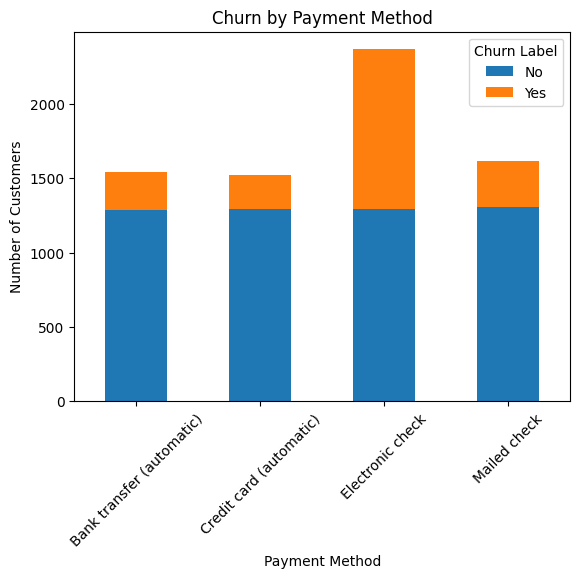

In [10]:
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

print(payment_churn)

payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

This analysis explores how different payment methods affect churn behaviour. By analysing categories such as electronic check, bank transfer, credit card, and mailed check, we can identify patterns in customer retention. Certain payment methods may be associated with higher churn due to inconvenience, lack of automation, or user preferences.

**9. Churn by Internet Service.**

Churn Label         No   Yes
Internet Service            
DSL               1962   459
Fiber optic       1799  1297
No                1413   113


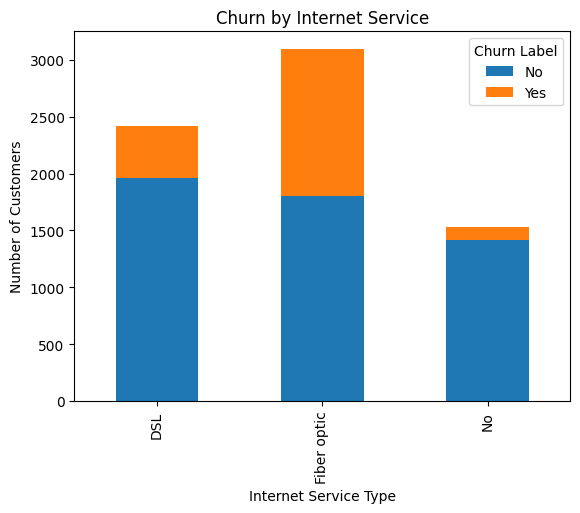

In [11]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

print(internet_churn)

internet_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

This section investigates the relationship between internet service type (DSL, Fiber Optic, or no internet) and customer churn. It helps determine whether customers using certain services are more likely to leave. For example, higher churn in fiber optic users may indicate pricing issues or service dissatisfaction.

**10. Numeric Correlation Analysis.**

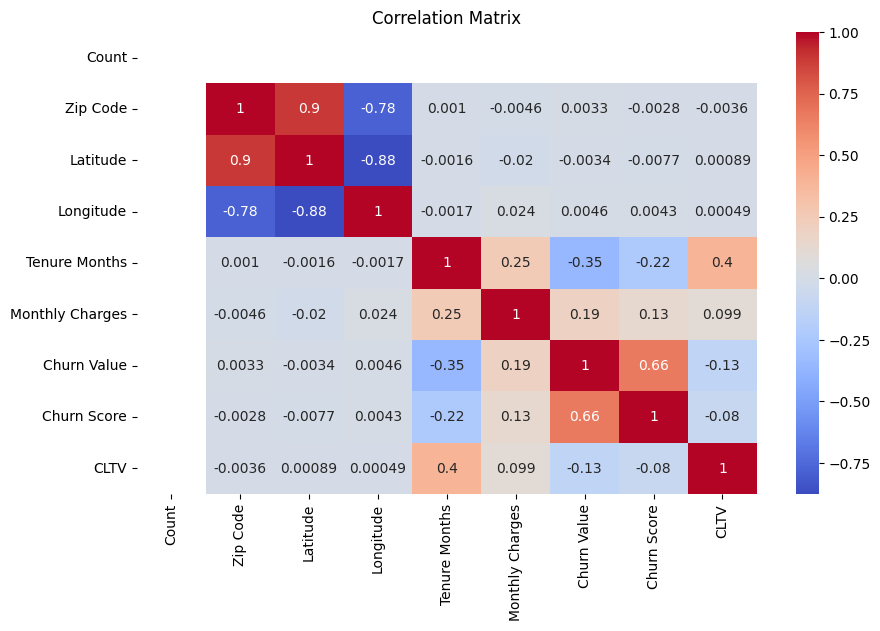

In [12]:
# select numeric columns
numeric_df = df.select_dtypes(include=["int64","float64"])

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

This analysis uses a correlation matrix to examine relationships between numerical variables such as tenure, monthly charges, and total charges. Correlation values help identify which variables are strongly related to each other and potentially influence churn. Strong positive or negative correlations can highlight key factors affecting customer behaviour.

**11. Fix Data Types.**

In [13]:
# convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# check data types
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In this step, incorrect data types are corrected to ensure accurate analysis. For example, the Total Charges column may be stored as a string instead of a numeric value. Converting it into a numeric format allows proper calculations and statistical analysis.

**12. Handle Missing Data.**

In [14]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Missing values can negatively impact analysis and model performance. In this dataset, missing values in the Total Charges column are replaced using the median value, which is less affected by outliers. This ensures data completeness without significantly distorting the distribution.

**13. Remove Duplicate Records.**

In [15]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Duplicate records can lead to biased results and inaccurate insights. Therefore, duplicate rows are identified and removed to ensure each customer is represented only once in the dataset. This improves data quality and reliability.

**14. Encode Categorical Variables.**

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encode churn label
df["Churn Label"] = le.fit_transform(df["Churn Label"])
df_encoded = pd.get_dummies(df, drop_first=True)

Machine learning models require numerical input, so categorical variables such as contract type, payment method, and gender must be converted into numerical form. This is achieved using label encoding and one-hot encoding, which transform categorical values into a format suitable for analysis and modelling.

# Stage 3: Data Mining and Business Insights

## Logistic Regression for Customer Churn Prediction

Based on the patterns uncovered during EDA — particularly the strong associations between contract type, internet service, monthly charges, and churn — a **Logistic Regression** model is selected as the first modelling technique.

**Justification for Logistic Regression:**
Logistic Regression is a well-established classification algorithm well-suited to binary outcomes such as churn (Yes/No). It is interpretable, computationally efficient, and produces probability scores for each customer — a property that is particularly valuable for business applications where a churn probability score can be used to prioritise retention interventions. It also provides feature coefficients, which allow the business to understand *which* factors most strongly drive churn (Hosmer, Lemeshow and Sturdivant, 2013).

### Step 1: Feature Selection and Train/Test Split

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# reproduce the cleaned, encoded dataframe from Stage 2 
df = pd.read_csv('data/Telco_customer_churn.csv')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.drop_duplicates()
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

le = LabelEncoder()
df['Churn Label'] = le.fit_transform(df['Churn Label'])  # No=0, Yes=1

# drop columns that are identifiers or leakage risks
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City',
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# one-hot encode remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# check for any remaining NaNs after encoding
nan_count = df_encoded.isna().sum().sum()
print(f'NaN values remaining after encoding: {nan_count}')
# Define features (X) and target (y)
X = df_encoded.drop(columns=['Churn Label'])
y = df_encoded['Churn Label']

# impute any remaining NaNs in X using the median strategy
# this handles edge cases where get_dummies leaves NaNs in numeric columns
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'NaN values after imputation: {X.isna().sum().sum()}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')


NaN values remaining after encoding: 11
NaN values after imputation: 0
Feature matrix shape: (7043, 30)
Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_24300\1541124860.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


Identifier columns (e.g. `CustomerID`) and direct churn leakage columns (e.g. `Churn Score`, `Churn Reason`) are removed before modelling. Including these would cause **data leakage** — the model would effectively be given the answer, producing artificially inflated performance metrics that would not generalise to unseen customers (Kaufman et al., 2012).

In [18]:
# train/test split — 80% training, 20% testing
# stratify=y ensures both splits preserve the 73/27 class balance seen in EDA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} rows')
print(f'Test set size     : {X_test.shape[0]} rows')
print(f'\nTrain churn rate  : {y_train.mean():.2%}')
print(f'Test churn rate   : {y_test.mean():.2%}')

Training set size : 5634 rows
Test set size     : 1409 rows

Train churn rate  : 26.54%
Test churn rate   : 26.54%


An 80/20 train-test split is used, which is a standard proportion that provides sufficient data for training while retaining enough unseen samples for reliable evaluation. `stratify=y` is applied to maintain the same class imbalance ratio in both subsets, preventing an unrepresentative test set.

### Step 2: Feature Scaling

In [19]:
# StandardScaler normalises features to zero mean and unit variance
# this is essential for Logistic Regression as it is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit only on training data to prevent data leakage

print('Scaling complete. Sample means (should be ~0):', X_train_scaled.mean(axis=0)[:5].round(4))

Scaling complete. Sample means (should be ~0): [-0. -0. -0.  0.  0.]


**Why scale?** Logistic Regression uses gradient-based optimisation. Without scaling, features with large ranges (e.g. `Total Charges` up to £8,000) dominate those with small ranges (e.g. binary flags), causing the optimiser to converge slowly or produce poorly calibrated coefficients. The scaler is fitted **only on training data** and then applied to the test set — fitting on the full dataset would constitute data leakage.

### Step 3: Train the Logistic Regression Model

In [20]:
# max_iter=1000 ensures convergence on this feature-rich dataset
# class_weight='balanced' adjusts for the 73/27 class imbalance,
# preventing the model from simply predicting 'No Churn' for everyone
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print(f'Number of iterations to converge: {lr_model.n_iter_[0]}')

Model trained successfully.
Number of iterations to converge: 34


`class_weight='balanced'` is a key modelling decision given the 73/27 class imbalance identified during EDA. Without this, the model would be biased toward predicting 'No Churn' for the majority of customers, achieving a high overall accuracy while performing poorly at identifying actual churners — the very customers a retention strategy needs to target.

### Step 4: Evaluate Model Performance

In [21]:
y_pred       = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8486


**Interpreting the metrics:**

- **Precision (Churn):** Of all customers the model flags as likely to churn, what proportion actually did? A low precision means many false alarms — retention resources are wasted on customers who were not going to leave.
- **Recall (Churn):** Of all customers who actually churned, what proportion did the model catch? Low recall means churners are missed — the most costly error from a business perspective.
- **F1-Score:** The harmonic mean of precision and recall, providing a single balanced metric particularly useful when classes are imbalanced.
- **ROC-AUC:** Measures the model's ability to distinguish between churners and non-churners across all possible probability thresholds. A score of 1.0 is perfect; 0.5 is no better than random guessing.

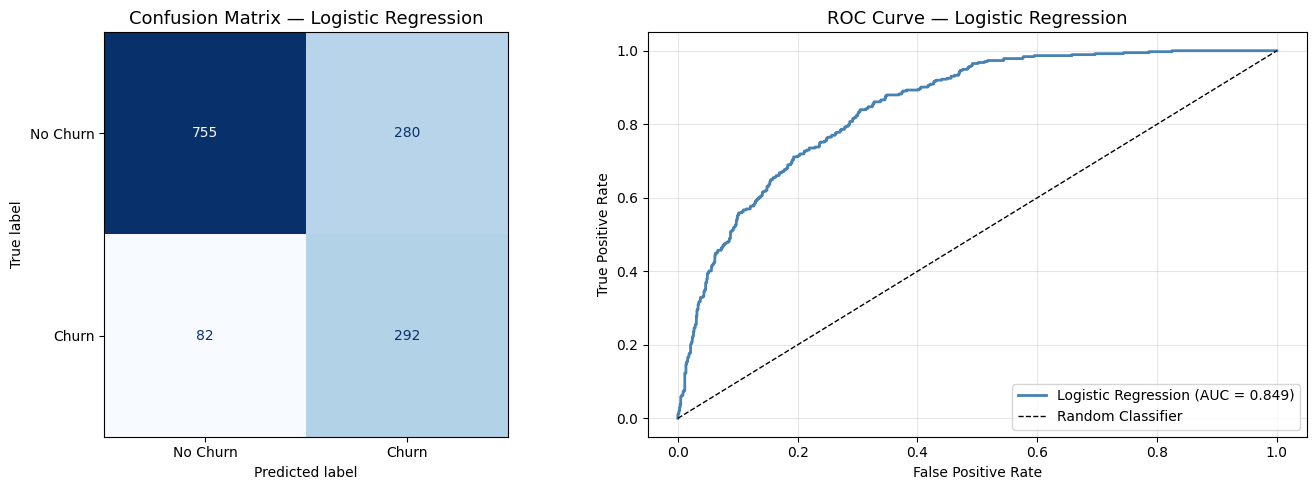

Visualisations saved.


In [22]:
#Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression', fontsize=13)

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisations saved.')

The **Confusion Matrix** reveals the four prediction outcomes in absolute numbers: true negatives (correctly predicted non-churners), false positives (customers incorrectly flagged as churners), false negatives (missed churners — the costliest errors), and true positives (correctly identified churners).

The **ROC Curve** plots the trade-off between the True Positive Rate (sensitivity) and the False Positive Rate at every possible classification threshold. The further the curve bows toward the top-left corner, the better the model's discriminatory power.

### Step 5: Feature Importance — What Drives Churn?

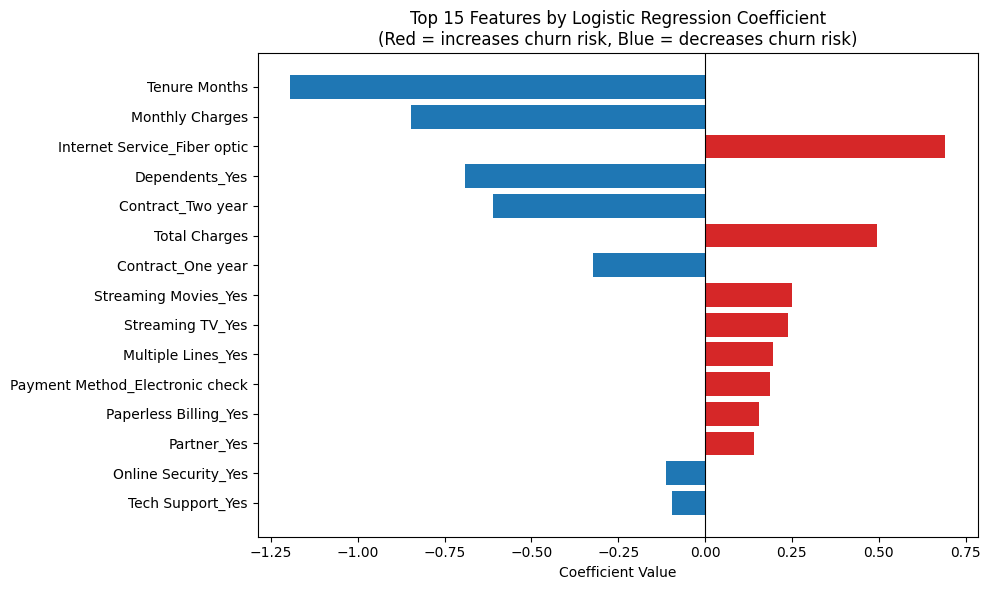

In [23]:
# extract coefficients as a measure of feature importance
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top_n = 15
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colours = ['#d62728' if c > 0 else '#1f77b4' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Features by Logistic Regression Coefficient\n'
             '(Red = increases churn risk, Blue = decreases churn risk)', fontsize=12)
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Intelligence Interpretation of Feature Coefficients:**

The coefficients from a Logistic Regression model are directly interpretable. A positive coefficient indicates that as that feature increases, the log-odds of churn increase (i.e. the customer is more likely to leave). A negative coefficient indicates a protective effect against churn.

Features with the largest absolute coefficients are the most influential drivers of the model's predictions, and consequently represent the most actionable levers for the business. For example:
- If **Month-to-Month Contract** has a large positive coefficient, this confirms the EDA finding that short-term contracts are the highest churn risk segment, and the business should prioritise converting these customers to longer-term agreements.
- If **Tenure Months** has a large negative coefficient, this confirms that loyal, long-tenured customers are significantly less likely to churn — suggesting that early engagement and onboarding programmes are critical to reducing churn in the long term.
- High positive coefficients on **Fiber Optic internet** align with the bivariate analysis from Stage 2, potentially pointing to pricing dissatisfaction or service quality concerns in that segment.

### Step 6: Churn Probability Scoring — A Practical Business Tool

Beyond simple yes/no classification, Logistic Regression provides a **probability score** for each customer. This is particularly valuable for prioritising retention efforts — a customer with an 85% predicted churn probability warrants a different intervention than one at 52%.

High-risk customers (probability ≥ 75%): 316
      Churn Probability  Actual Churn  Predicted Churn
886              0.9486             1                1
684              0.9374             1                1
1827             0.9334             1                1
1681             0.9333             1                1
2567             0.9316             0                1
1818             0.9307             1                1
3732             0.9258             0                1
1044             0.9245             1                1
590              0.9232             1                1
978              0.9231             1                1


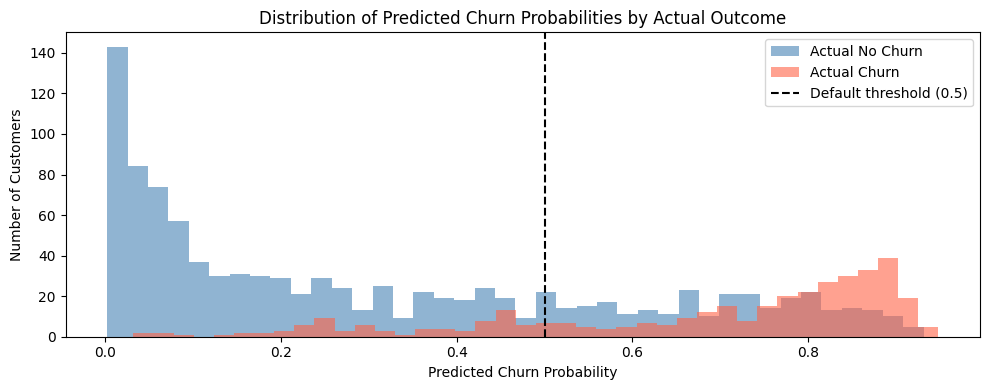

In [24]:
# attach churn probability scores to the test set
results_df = X_test.copy()
results_df['Actual Churn']      = y_test.values
results_df['Predicted Churn']   = y_pred
results_df['Churn Probability'] = y_pred_proba.round(4)

# display highest-risk customers
high_risk = results_df[results_df['Churn Probability'] >= 0.75].sort_values(
    'Churn Probability', ascending=False
)
print(f'High-risk customers (probability ≥ 75%): {len(high_risk)}')
print(high_risk[['Churn Probability', 'Actual Churn', 'Predicted Churn']].head(10))

# visualise distribution of churn probabilities
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results_df[results_df['Actual Churn'] == 0]['Churn Probability'],
        bins=40, alpha=0.6, label='Actual No Churn', color='steelblue')
ax.hist(results_df[results_df['Actual Churn'] == 1]['Churn Probability'],
        bins=40, alpha=0.6, label='Actual Churn', color='tomato')
ax.axvline(0.5, color='black', linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Predicted Churn Probabilities by Actual Outcome')
ax.legend()
plt.tight_layout()
plt.savefig('lr_probability_dist.png', dpi=150, bbox_inches='tight')
plt.show()

The probability distribution chart is a key business intelligence output. A well-performing model will show two clearly separated humps — one cluster of non-churners scoring low probability, and one cluster of churners scoring high probability. Overlap in the middle represents customers the model is uncertain about, which is where human judgement or additional data could add most value.

From an operational standpoint, the business can use these probability scores to define tiered retention programmes:
- **≥ 75% probability:** High-priority intervention — personal outreach, loyalty discounts, or account reviews.
- **50–74% probability:** Medium-priority — targeted email campaigns or automated service check-ins.
- **< 50% probability:** Low risk — standard retention communications are sufficient.